# Desafío - Fundamentos de análisis exploratorio y estadística descriptiva 
### Nombre: Matías Ignacio Ramírez Benavides

# Descripción 
Imagina que eres un analista de datos para una empresa de distribución de videojuegos. Se te ha entregado un conjunto de datos con las ventas de varios videojuegos en diferentes  regiones y se te ha pedido que realices un análisis exploratorio para extraer información valiosa que pueda guiar las futuras estrategias de marketing.

## Objetivos de Evaluación 
* Aplicar  análisis  exploratorio  de  datos  distinguiendo  sus  principales  técnicas  y herramientas. 
* Aplicar  los  conceptos  fundamentales  de  estadística  descriptiva  para  la caracterización de un conjunto de datos a partir de un problema dado. 

# Requerimientos
## 1. Generación y Carga del Conjunto de Datos (1 Punto) 
* Primero, ejecuta este bloque de código para crear tu conjunto de datos de 
trabajo. 

In [1]:
# Librerías
import numpy as np 
import pandas as pd 
 
np.random.seed(42) # Semilla "aleatoria" 
n = 100 
 
plataformas = ["Xbox", "PlayStation", "Nintendo", "PC"] # lista 1
generos = ["Acción", "Aventura", "Estrategia", "Deportes", "RPG"] # lista 2
 
data = { 
    "Nombre": [f"Juego_{i}" for i in range(n)], # crea lista de nombres de juegos según la cantidad definida en n
    "Plataforma": np.random.choice(plataformas, n), # selecciona n valores de la lista plataformas de forma aleatoria
    "Anio_Lanzamiento": np.random.randint(2010, 2023, n), # genera n años dentro del rango de 2010 a 2022 ya que el 2023 se excluye
    "Genero": np.random.choice(generos, n), # selecciona n cantidad de géneros de forma aleatoria 
    "Ventas_NA": np.random.uniform(0.1, 15, n), # genera ventas aleatorias entre 0.1 y 15 para NA
    "Ventas_EU": np.random.uniform(0.1, 10, n), # genera ventas aleatorias entre 0.1 y 10 para EU
    "Ventas_JP": np.random.uniform(0.05, 5, n), # genera ventas aleatorias entre 0.05 y 5 para JP
    "Critica_Puntaje": np.random.randint(40, 100, n).astype(float) # genera valores aleatorios entre 40 y 100 y luego los convierte a float (para permitir valores NaN)
} 
 
df = pd.DataFrame(data) 
 
#  Introducir  valores  nulos  en  Critica_Puntaje (simulando datos faltantes reales) 
nulos_idx = np.random.choice(df.index, size=10, replace=False) 
df.loc[nulos_idx, "Critica_Puntaje"] = np.nan 
 
df.to_csv("Videojuegos.csv", index=False) 
df.head()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Nintendo,2011,RPG,13.516229,8.243746,1.891490,47.0
1,Juego_1,PC,2019,Acción,9.533212,3.665887,3.893244,97.0
2,Juego_2,Xbox,2021,RPG,5.151544,1.357899,1.736978,67.0
3,Juego_3,Nintendo,2011,Deportes,5.303223,5.270208,4.657249,75.0
4,Juego_4,Nintendo,2019,Deportes,10.916740,7.722936,4.299143,65.0


## 2. Análisis Exploratorio Inicial (IDA) (4 Puntos) 
*  Realiza una inspección básica para familiarizarte con los datos. 
*  Inspección del DataFrame: 
    *  Muestra las primeras y las últimas 5 filas del DataFrame. 
    *  Obtén información general del DataFrame utilizando el método .info(). ¿Hay valores nulos? ¿Qué tipos de datos tiene cada columna? 
    *  Calcula las dimensiones del DataFrame. 

In [6]:
from IPython.display import display # importa la función display para mostrar DataFrames de manera más legible en Jupyter Notebook
display(df.head(5)) # por defecto ya muestra 5 primeras filas
display(df.tail(5)) # por defecto ya muestra 5 ultimas filas
print("="*50 + "\n" +" "*10 + "Información del DataFrame:\n" + "="*50)
df.info()
print(f"\n\nDimensiones del Dataframe: {df.shape}")

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Nintendo,2011,RPG,13.516229,8.243746,1.891490,47.0
1,Juego_1,PC,2019,Acción,9.533212,3.665887,3.893244,97.0
2,Juego_2,Xbox,2021,RPG,5.151544,1.357899,1.736978,67.0
3,Juego_3,Nintendo,2011,Deportes,5.303223,5.270208,4.657249,75.0
4,Juego_4,Nintendo,2019,Deportes,10.916740,7.722936,4.299143,65.0


,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
95,Juego_95,PlayStation,2012,Acción,8.185405,1.856651,1.440768,88.0
96,Juego_96,PlayStation,2015,Aventura,4.369465,7.531086,4.754537,79.0
97,Juego_97,PC,2021,Acción,8.903416,8.087664,4.456806,NaN
98,Juego_98,PlayStation,2011,Deportes,0.554454,9.906001,2.305501,NaN
99,Juego_99,Xbox,2019,RPG,0.656488,4.184915,3.119656,67.0


          Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nombre            100 non-null    object 
 1   Plataforma        100 non-null    object 
 2   Anio_Lanzamiento  100 non-null    int32  
 3   Genero            100 non-null    object 
 4   Ventas_NA         100 non-null    float64
 5   Ventas_EU         100 non-null    float64
 6   Ventas_JP         100 non-null    float64
 7   Critica_Puntaje   90 non-null     float64
dtypes: float64(4), int32(1), object(3)
memory usage: 6.0+ KB


Dimensiones del Dataframe: (100, 8)


* solo hay 10 valores nulos en "Critica_Puntaje"
* Las columnas "Nombre", "Plataforma" y "Genero" cuentan con valores del tipo objeto (Texto)
* Las columnas "Ventas_NA", "Ventas_EU", "Ventas_JP" y "Critica_Puntaje" son del tipo float (valores con decimal)
* La columna "Anio_Lanzamiento" es del tipo entero


## 3. Análisis Descriptivo y Univariado (5 Puntos) 
*  Profundiza en el análisis de variables individuales. 
*  Variables Numéricas: 
    *  Calcula  y  describe  las  principales  medidas  de  tendencia  central (media, mediana) y de dispersión (desviación estándar, rango) para las  columnas  de  ventas  (Ventas_NA,  Ventas_EU,  Ventas_JP) y Critica_Puntaje. 


In [ ]:
# Calculo de media y mediana de ventas por región
#( La media representa el promedio, mientras que la mediana es el valor que queda justo en el centro cuando los datos se ordenan. )
media_NA = df["Ventas_NA"].mean()
media_EU = df["Ventas_EU"].mean()
media_JP = df["Ventas_JP"].mean()
media_critica = df["Critica_Puntaje"].mean()
mediana_NA = df["Ventas_NA"].median()
mediana_EU = df["Ventas_EU"].median()
mediana_JP = df["Ventas_JP"].median()
mediana_critica = df["Critica_Puntaje"].median()

# Desviación estándar y rango
# (La desviación estándar indica cuánto se alejan los datos del promedio, mientras que el rango muestra la diferencia entre el valor máximo y mínimo.)
desviacion_NA = df["Ventas_NA"].std()
desviacion_EU = df["Ventas_EU"].std()
desviacion_JP = df["Ventas_JP"].std()
desviacion_critica = df["Critica_Puntaje"].std()
rango_NA = df["Ventas_NA"].max() - df["Ventas_NA"].min()
rango_EU = df["Ventas_EU"].max() - df["Ventas_EU"].min()
rango_JP = df["Ventas_JP"].max() - df["Ventas_JP"].min()
rango_critica = df["Critica_Puntaje"].max() - df["Critica_Puntaje"].min()
print("="*50 + "\n" +" "*8 + "Medidas  de  tendencia  central:\n" + "="*50)
print(f"Mediana Ventas NA: {mediana_NA:.2f} | Media Ventas NA: {media_NA:.2f}")
print(f"Mediana Ventas EU: {mediana_EU:.2f} | Media Ventas EU: {media_EU:.2f}")
print(f"Mediana Ventas JP: {mediana_JP:.2f} | Media Ventas JP: {media_JP:.2f}")
print(f"Mediana Crítica: {mediana_critica:.2f}  | Media Crítica: {media_critica:.2f}")
print("\n" +"="*70 + "\n" +" "*22 + "Medidas  de  dispersión:\n" + "="*70)
print(f"Desviación estándar Ventas NA: {desviacion_NA:.2f} | Rango Ventas NA: {rango_NA:.2f}")
print(f"Desviación estándar Ventas EU: {desviacion_EU:.2f} | Rango Ventas EU: {rango_EU:.2f}")
print(f"Desviación estándar Ventas JP: {desviacion_JP:.2f} | Rango Ventas JP: {rango_JP:.2f}")
print(f"Desviación estándar Crítica: {desviacion_critica:.2f}  | Rango Crítica: {rango_critica:.2f}")

        Medidas  de  tendencia  central:
Mediana Ventas NA: 8.71 | Media Ventas NA: 8.11
Mediana Ventas EU: 5.02 | Media Ventas EU: 4.80
Mediana Ventas JP: 2.78 | Media Ventas JP: 2.67
Mediana Crítica: 67.00  | Media Crítica: 68.93

                      Medidas  de  dispersión:
Desviación estándar Ventas NA: 4.36 | Rango Ventas NA: 14.68
Desviación estándar Ventas EU: 2.90 | Rango Ventas EU: 9.66
Desviación estándar Ventas JP: 1.55 | Rango Ventas JP: 4.86
Desviación estándar Crítica: 17.47  | Rango Crítica: 59.00


*  Visualización:  
    *  Genera histogramas para visualizar la distribución de las ventas en Norteamérica  (Ventas_NA)  y  de  los  puntajes  de  la  crítica  (Critica_Puntaje). ¿Qué observas en estas distribuciones? 
    * Genera diagramas de caja (boxplots) para las ventas en cada región. ¿Existen valores atípicos? 


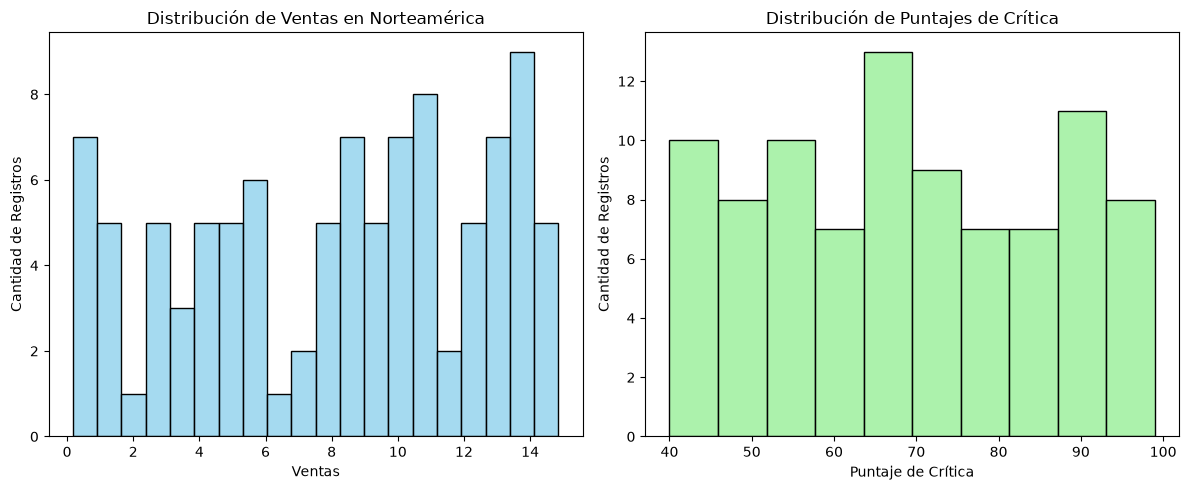

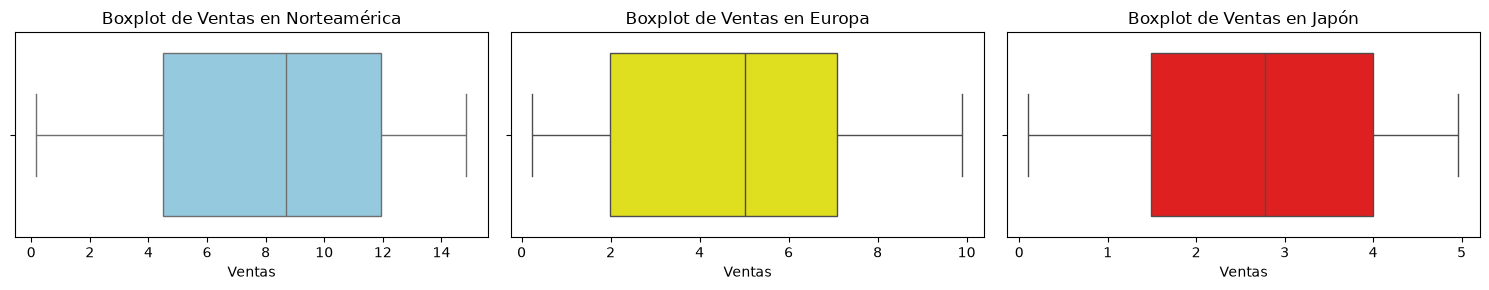

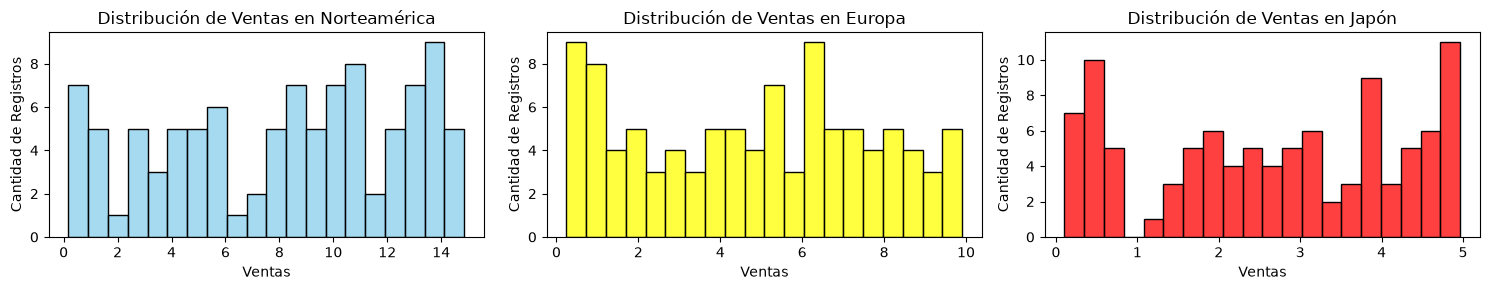

,Ventas_NA,Ventas_EU,Ventas_JP
Q1,4.48,1.99,1.49
Q2,8.71,5.02,2.78
Q3,11.95,7.09,3.99
IQR,7.46,5.10,2.50


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
#-------------- Histograma Ventas NA y Puntajes de Crítica --------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Crear una figura con 1 fila y 2 columnas
# Histograma de Ventas NA
sns.histplot(data=df, x="Ventas_NA", bins=20, color="skyblue", edgecolor="black", ax=axes[0])
axes[0].set_title("Distribución de Ventas en Norteamérica")
axes[0].set_xlabel("Ventas")
axes[0].set_ylabel("Cantidad de Registros")

# Histograma de Puntajes de Crítica
sns.histplot(data=df, x="Critica_Puntaje", bins=10, color="lightgreen", edgecolor="black", ax=axes[1])
axes[1].set_title("Distribución de Puntajes de Crítica")
axes[1].set_xlabel("Puntaje de Crítica")
axes[1].set_ylabel("Cantidad de Registros")
plt.tight_layout() # Ajustar el espacio entre gráficos
plt.show() # Mostrar la figura

#-------------- Boxplot Ventas NA, EU y JP --------------

# Boxplot de ventas NA, EU y JP
fig, axes = plt.subplots(1, 3, figsize=(15, 3)) # Crear una figura con 1 fila y 3 columnas
sns.boxplot(data=df, x="Ventas_NA", color="skyblue", ax=axes[0])
axes[0].set_title("Boxplot de Ventas en Norteamérica")
axes[0].set_xlabel("Ventas")

sns.boxplot(data=df, x="Ventas_EU", color="yellow", ax=axes[1])
axes[1].set_title("Boxplot de Ventas en Europa")
axes[1].set_xlabel("Ventas")

sns.boxplot(data=df, x="Ventas_JP", color="red", ax=axes[2])
axes[2].set_title("Boxplot de Ventas en Japón")
axes[2].set_xlabel("Ventas")

plt.tight_layout()
plt.show()

#-------------- Histograma Ventas NA, EU y JP para visualizar--------------

fig, axes = plt.subplots(1, 3, figsize=(15, 3)) # Crear una figura con 1 fila y 2 columnas
# Histograma de Ventas NA
sns.histplot(data=df, x="Ventas_NA", bins=20, color="skyblue", edgecolor="black", ax=axes[0])
axes[0].set_title("Distribución de Ventas en Norteamérica")
axes[0].set_xlabel("Ventas")
axes[0].set_ylabel("Cantidad de Registros")

# Histograma de Ventas EU
sns.histplot(data=df, x="Ventas_EU", bins=20, color="yellow", edgecolor="black", ax=axes[1])
axes[1].set_title("Distribución de Ventas en Europa")
axes[1].set_xlabel("Ventas")
axes[1].set_ylabel("Cantidad de Registros")

# Histograma de Ventas JP
sns.histplot(data=df, x="Ventas_JP", bins=20, color="red", edgecolor="black", ax=axes[2])
axes[2].set_title("Distribución de Ventas en Japón")
axes[2].set_xlabel("Ventas")
axes[2].set_ylabel("Cantidad de Registros")
plt.tight_layout() # Ajustar el espacio entre gráficos
plt.show() # Mostrar la figura

#-------------- Cuartiles e IQR para visualizar --------------

columnas = ["Ventas_NA", "Ventas_EU", "Ventas_JP"]
resumen = pd.DataFrame(index=["Q1", "Q2", "Q3", "IQR"])
for columna in columnas:
    q1 = df[columna].quantile(0.25)
    q2 = df[columna].quantile(0.50)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    resumen[columna] = [q1, q2, q3, iqr]
display(resumen.round(2)) # redondea los valores a 2 decimales y muestra

### Histograma
+ No presentan valores atípicos ninguna de las dos ya que no hay valores tan alejados del resto de valores.
+ Se observa en las ventas en Norteamérica son ligeramente uniformes ya que están ligeramente dispersas a lo largo de todo el rango.
+ Para jes de critica se ve que los valores están distribuidos en el rango de 40 a 100 y que presenta valores altos en 65 y 90 aprox.


### Bloxplot
* En ninguno de los BoxPlot se encuentran valores atípicos 
* Se puede visualizar que la mediana (Q2) para cada gráfica esta aproximada al centro
* Norteamérica presenta una mayor variabilidad en ventas ya que tiene el mayor rango intercuatil (IQR) luego sigue Europa y finalmente Japón como el IQR mas pequeño

*  Variables Categóricas: 
    *  Utiliza  tablas  de  frecuencia  para  contar  cuántos  juegos  hay  por Plataforma y Genero. 
    *  Visualización: Crea un gráfico de barras para mostrar la cantidad de juegos por Genero. ¿Cuál es el género más común en este conjunto de datos?

Plataforma
PC             30
PlayStation    26
Nintendo       24
Xbox           20
Name: count, dtype: int64

Genero
Acción        29
Deportes      26
Estrategia    20
Aventura      15
RPG           10
Name: count, dtype: int64

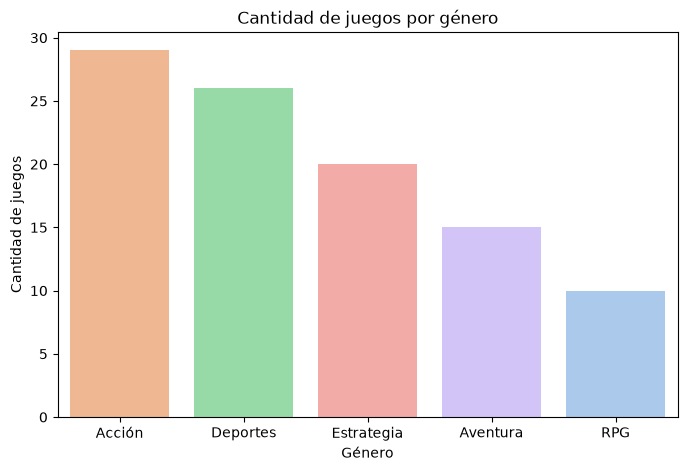

In [4]:
frecuencia_plataforma = df["Plataforma"].value_counts()
frecuencia_genero = df["Genero"].value_counts()
display(frecuencia_plataforma)
display(frecuencia_genero)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Genero", palette="pastel", order=df["Genero"].value_counts().index, hue="Genero") # agregue hue="Genero" para que no muestre una alerta de la librería.
plt.title("Cantidad de juegos por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.show()

El genero mas común es el de Acción.